In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

c:\Users\Marcel\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Marcel\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
billboard = pd.read_csv('hot100.csv')
billboard.columns

C:\Users\Marcel\AppData\Local\Temp\ipykernel_18284\3015988688.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  billboard = pd.read_csv('hot100.csv')


Index(['Date', 'Song', 'Artist', 'Rank', 'Last Week', 'Peak Position',
       'Weeks in Charts', 'Image URL'],
      dtype='object')

In [4]:
billboard.drop(columns=['Image URL'], inplace=True)
billboard.head()

,Date,Song,Artist,Rank,Last Week,Peak Position,Weeks in Charts
0,1958-08-06,Poor Little Fool,Ricky Nelson,1,1,1,2
1,1958-08-06,Nel Blu Dipinto Di Blu (Volare),Domenico Modugno,2,54,2,2
2,1958-08-06,Patricia,Perez Prado And His Orchestra,3,2,2,2
3,1958-08-06,Splish Splash,Bobby Darin,4,3,3,2
4,1958-08-06,When,Kalin Twins,5,5,5,2


In [5]:
spotify = pd.read_csv('dataset-of-10s.csv')
spotify.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target
0,Wild Things,Alessia Cara,spotify:track:2ZyuwVvV6Z3XJaXIFbspeE,0.741,0.626,1,-4.826,0,0.0886,0.02000,0.000,0.0828,0.706,108.029,188493,4,41.18681,10,1
1,Surfboard,Esquivel!,spotify:track:61APOtq25SCMuK0V5w2Kgp,0.447,0.247,5,-14.661,0,0.0346,0.87100,0.814,0.0946,0.250,155.489,176880,3,33.18083,9,0
2,Love Someone,Lukas Graham,spotify:track:2JqnpexlO9dmvjUMCaLCLJ,0.550,0.415,9,-6.557,0,0.0520,0.16100,0.000,0.1080,0.274,172.065,205463,4,44.89147,9,1
3,Music To My Ears (feat. Tory Lanez),Keys N Krates,spotify:track:0cjfLhk8WJ3etPTCseKXtk,0.502,0.648,0,-5.698,0,0.0527,0.00513,0.000,0.2040,0.291,91.837,193043,4,29.52521,7,0
4,Juju On That Beat (TZ Anthem),Zay Hilfigerrr & Zayion McCall,spotify:track:1lItf5ZXJc1by9SbPeljFd,0.807,0.887,1,-3.892,1,0.2750,0.00381,0.000,0.3910,0.780,160.517,144244,4,24.99199,8,1


In [6]:
def normalize_title(title):
    title = title.lower()
    title = re.sub(r"\(.*?\)", "", title) #remove text in parentheses
    title = re.sub(r"feat\.|featuring", "", title) #remove 'feat.' or 'featuring' -> can look into it later
    title = re.sub(r'[^a-z0-9\s]', '', title) #delete punctuation
    title = re.sub(r'\s+', ' ', title).strip() #remove extra spaces
    return title


In [7]:
billboard['Normalized Title'] = billboard['Song'].apply(normalize_title)
spotify['Normalized Title'] = spotify['track'].apply(normalize_title)

In [8]:
spotify.head()

,track,artist,uri,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,chorus_hit,sections,target,Normalized Title
0,Wild Things,Alessia Cara,spotify:track:2ZyuwVvV6Z3XJaXIFbspeE,0.741,0.626,1,-4.826,0,0.0886,0.02000,0.000,0.0828,0.706,108.029,188493,4,41.18681,10,1,wild things
1,Surfboard,Esquivel!,spotify:track:61APOtq25SCMuK0V5w2Kgp,0.447,0.247,5,-14.661,0,0.0346,0.87100,0.814,0.0946,0.250,155.489,176880,3,33.18083,9,0,surfboard
2,Love Someone,Lukas Graham,spotify:track:2JqnpexlO9dmvjUMCaLCLJ,0.550,0.415,9,-6.557,0,0.0520,0.16100,0.000,0.1080,0.274,172.065,205463,4,44.89147,9,1,love someone
3,Music To My Ears (feat. Tory Lanez),Keys N Krates,spotify:track:0cjfLhk8WJ3etPTCseKXtk,0.502,0.648,0,-5.698,0,0.0527,0.00513,0.000,0.2040,0.291,91.837,193043,4,29.52521,7,0,music to my ears
4,Juju On That Beat (TZ Anthem),Zay Hilfigerrr & Zayion McCall,spotify:track:1lItf5ZXJc1by9SbPeljFd,0.807,0.887,1,-3.892,1,0.2750,0.00381,0.000,0.3910,0.780,160.517,144244,4,24.99199,8,1,juju on that beat


In [9]:
billboard_columns = ['Date', 'Song', 'Artist', 'Rank', 'Last Week', 'Peak Position', 'Weeks in Charts', 'Normalized Title']
spotify_columns = ['Track', 'Artist', 'Uri', 'Danceability', 'Energy', 'Key', 'Loudness',
       'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness',
       'Valence', 'Tempo', 'Duration_ms', 'Time_signature', 'Chorus_hit',
       'Sections', 'Target', 'Normalized Title']
billboard.columns = billboard_columns
spotify.columns = spotify_columns

In [10]:
merged_data = pd.merge(billboard, spotify, on=['Normalized Title', "Artist"], how='inner', suffixes=('_billboard', '_spotify'))

In [11]:
merged_data['Weeks in Charts'] = pd.to_numeric(merged_data['Weeks in Charts'], errors='coerce').astype('Int64')
#merged_data['Weeks in Charts'] = merged_data['Weeks in Charts'].fillna(None).astype('Int64')

In [12]:
#merged_data.head()
#merged_data["Weeks in Charts"] = int(merged_data["Weeks in Charts"])
filtered_data = merged_data[merged_data['Normalized Title'] == 'sugar']
#filtered_data = filtered_data[filtered_data["Weeks in Charts"] < 6]
filtered_data #most likely will drop Peak Position as it is not relevant to the analysis of audio features.

,Date,Song,Artist,Rank,Last Week,Peak Position,Weeks in Charts,Normalized Title,Track,Uri,...,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_ms,Time_signature,Chorus_hit,Sections,Target
24881,2015-01-28,Sugar,Maroon 5,8,8,1,<NA>,sugar,Sugar,spotify:track:3ZKUZe1oUDnEUOQkzBJjf6,...,0.0472,0.0,0.0924,0.896,120.039,234440,4,72.55700,5,1
24970,2015-02-04,Sugar,Maroon 5,6,8,6,2,sugar,Sugar,spotify:track:3ZKUZe1oUDnEUOQkzBJjf6,...,0.0472,0.0,0.0924,0.896,120.039,234440,4,72.55700,5,1
25061,2015-02-11,Sugar,Maroon 5,5,6,5,3,sugar,Sugar,spotify:track:3ZKUZe1oUDnEUOQkzBJjf6,...,0.0472,0.0,0.0924,0.896,120.039,234440,4,72.55700,5,1
25151,2015-02-18,Sugar,Maroon 5,4,5,4,4,sugar,Sugar,spotify:track:3ZKUZe1oUDnEUOQkzBJjf6,...,0.0472,0.0,0.0924,0.896,120.039,234440,4,72.55700,5,1
25244,2015-02-25,Sugar,Maroon 5,5,4,4,5,sugar,Sugar,spotify:track:3ZKUZe1oUDnEUOQkzBJjf6,...,0.0472,0.0,0.0924,0.896,120.039,234440,4,72.55700,5,1
25330,2015-03-04,Sugar,Maroon 5,4,5,4,6,sugar,Sugar,spotify:track:3ZKUZe1oUDnEUOQkzBJjf6,...,0.0472,0.0,0.0924,0.896,120.039,234440,4,72.55700,5,1
25412,2015-03-11,Sugar,Maroon 5,3,4,3,7,sugar,Sugar,spotify:track:3ZKUZe1oUDnEUOQkzBJjf6,...,0.0472,0.0,0.0924,0.896,120.039,234440,4,72.55700,5,1
25500,2015-03-18,Sugar,Maroon 5,3,3,3,8,sugar,Sugar,spotify:track:3ZKUZe1oUDnEUOQkzBJjf6,...,0.0472,0.0,0.0924,0.896,120.039,234440,4,72.55700,5,1
25593,2015-03-25,Sugar,Maroon 5,2,3,2,9,sugar,Sugar,spotify:track:3ZKUZe1oUDnEUOQkzBJjf6,...,0.0472,0.0,0.0924,0.896,120.039,234440,4,72.55700,5,1
25686,2015-04-01,Sugar,Maroon 5,2,2,2,10,sugar,Sugar,spotify:track:3ZKUZe1oUDnEUOQkzBJjf6,...,0.0472,0.0,0.0924,0.896,120.039,234440,4,72.55700,5,1


In [13]:
#print(filtered_data.columns)
filtered_data.drop(columns=['Uri'], inplace=True)

C:\Users\Marcel\AppData\Local\Temp\ipykernel_18284\89679104.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(columns=['Uri'], inplace=True)


In [14]:
def plot_song_billboard_placement(song_title, song_artist):
    song_data = merged_data[(merged_data['Normalized Title'] == song_title) & (merged_data['Artist'] == song_artist)]
    if not song_data.empty:
        plt.figure(figsize=(10, 6))
        sns.lineplot(x='Date', y='Rank', data=song_data)
        plt.gca().invert_yaxis()  # Invert y-axis to show rank 1 at the top
        plt.title(f'Billboard Placement Over Time for "{song_title.title()}"')
        plt.xlabel('Date')
        plt.ylabel('Rank')
        plt.xticks(rotation=45)
        plt.grid()
        plt.show()
    else:
        print(f'No data found for the song "{song_title}".')

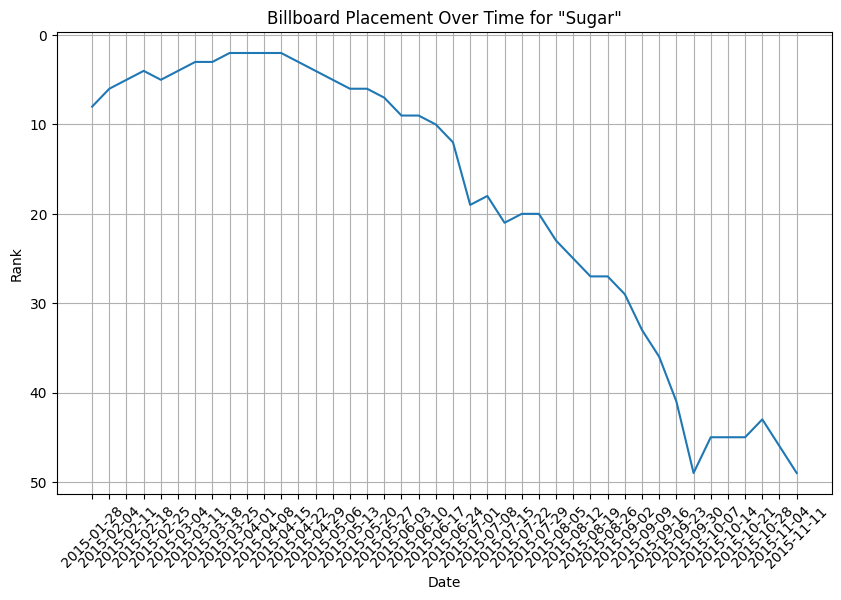

In [15]:
plot_song_billboard_placement('sugar', 'Maroon 5')

In [16]:
pd.DataFrame(filtered_data).to_csv('filtered_data.csv', index=False)

In [17]:
df00 = pd.read_csv('dataset-of-00s.csv')
df10 = pd.read_csv('dataset-of-10s.csv')
df90 = pd.read_csv('dataset-of-90s.csv')


00s that were on the billboard

In [ ]:
df00['Normalized Title'] = df00['track'].apply(normalize_title)


In [19]:
df00.size

117440

In [28]:
billboard_normalized_titles = billboard['Normalized Title'].unique()
billboard_artists = billboard['Artist'].unique()
df00_billboard = df00[df00['Normalized Title'].isin(billboard_normalized_titles) & df00['artist'].isin(billboard_artists)]
#df00_billboard = pd.merge(df00, billboard, left_on=['Normalized Title', 'artist'], right_on=['Normalized Title', 'Artist'], how='right', suffixes=('_spotify', '_billboard'))

In [ ]:
print(df00_billboard[df00_billboard['target'] == 0].size)
print(df00_billboard[df00_billboard['target'] == 1].size)
print(df00_billboard.size)
#billboard_normalized_titles
#almost all songs from the 00s which were in the billboard are considered hits by spotify dataset. Only small % is non-hit.

180
56620
56800
